# Data exploration

In [22]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

from sentiment_analysis.utils import PATH_TRAINING_DATASET, PATH_CLEANED_TRAINING_DATASET

### load the dataset

In [23]:
movie_reviews = pd.read_csv(PATH_TRAINING_DATASET)

In [24]:
movie_reviews.shape

(50000, 2)

In [25]:
movie_reviews.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [26]:
movie_reviews.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [27]:
# Checking for missing values
movie_reviews.isnull().values.any()

np.False_

## Clean duplicates

In [28]:
# Counting duplicate rows
duplicate_count = movie_reviews.duplicated().sum()

print(f"Number of duplicate reviews found: {duplicate_count}")

Number of duplicate reviews found: 418


In [29]:
# remove duplicate rows
if duplicate_count > 0:
    movie_reviews.drop_duplicates(inplace=True)

print(f"New shape after removing duplicates: {movie_reviews.shape}")

New shape after removing duplicates: (49582, 2)


<Axes: xlabel='sentiment', ylabel='count'>

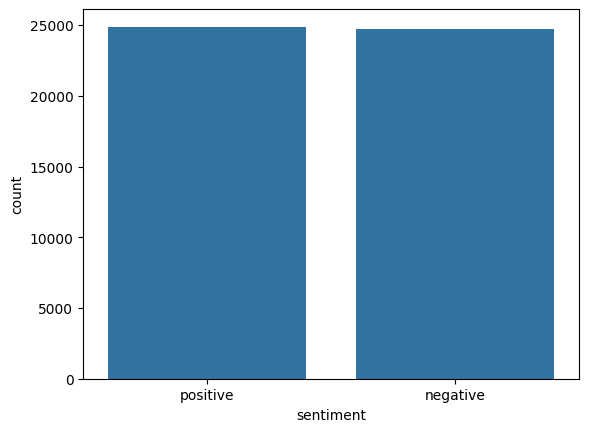

In [30]:
# Checking the distribution of positive/negative sentiments in the dataset
import seaborn as sns

sns.countplot(x='sentiment', data=movie_reviews)

In [31]:
# Calculating word count for each review
movie_reviews['review_len'] = movie_reviews['review'].apply(lambda x: len(x.split()))

print("Review Length Statistics")
print(movie_reviews['review_len'].describe())

Review Length Statistics
count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review_len, dtype: float64


In [32]:
# preview a sample
movie_reviews["review"][2]

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [33]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\andry\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
def clean_text(text):
    """ a function to clean the each text data"""
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    
    # Remove stopwords and short words (len < 2)
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]
    
    return " ".join(words)

In [35]:
# sample cleaned output
clean_text(movie_reviews["review"][2])

'thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty characters likable even well bread suspected serial killer may disappointed realize match point risk addiction thought proof woody allen still fully control style many us grown love laughed one woody comedies years dare say decade never impressed scarlet johanson managed tone sexy image jumped right average spirited young woman may crown jewel career wittier devil wears prada interesting superman great comedy go see friends'

In [36]:
# apply cleaning to the entire dataset
movie_reviews['review'] = movie_reviews['review'].apply(clean_text)

In [37]:
# sample cleaned output
clean_text(movie_reviews["review"][2])

'thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty characters likable even well bread suspected serial killer may disappointed realize match point risk addiction thought proof woody allen still fully control style many us grown love laughed one woody comedies years dare say decade never impressed scarlet johanson managed tone sexy image jumped right average spirited young woman may crown jewel career wittier devil wears prada interesting superman great comedy go see friends'

In [38]:
movie_reviews.shape

(49582, 3)

In [39]:
# Converting sentiment labels to 0 & 1
movie_reviews['sentiment'] = movie_reviews['sentiment'].map({'positive': 1, 'negative': 0})

In [40]:
# preview cleaned data
movie_reviews.head()

,review,sentiment,review_len
0,one reviewers mentioned watching oz episode ho...,1,307
1,wonderful little production filming technique ...,1,162
2,thought wonderful way spend time hot summer we...,1,166
3,basically family little boy jake thinks zombie...,0,138
4,petter mattei love time money visually stunnin...,1,230


In [43]:
# Save the cleaned dataset
movie_reviews.to_csv(PATH_CLEANED_TRAINING_DATASET, index=False)